# Exploratory analysis and data profiling using sample
Perform exploratory data analysis before moving to PySpark, including:

- missingno: missing-value visualizations
- sweetviz: html report
- Outlier detection: IQR and Z-score methods

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# visual conf
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

import glob


##  Upload SAMPLE fon analysis

In [ ]:
# Buscar todos los CSV
files = glob.glob('../data/raw/flights/*.csv.gz')
print(f"Files: {len(files)}")
import gzip

total_rows = 0


for file in files:
    # 'rt' means 'read text', which is necessary to detect newlines in a compressed file
    with gzip.open(file, 'rt', encoding='utf-8') as f:
        # We subtract 1 assuming the file has a header
        count = sum(1 for _ in f) - 1 
        print(f" {file}: {count:,} rows")
        total_rows += count

print(f" TOTAL  ROWS: {total_rows:,}")

Files: 6
 ../data/raw/flights\Flights_20211201_20211231.csv.gz: 570,200 rows
 ../data/raw/flights\Flights_20220301_20220331.csv.gz: 576,258 rows
 ../data/raw/flights\Flights_20220601_20220630.csv.gz: 813,452 rows
 ../data/raw/flights\Flights_20220901_20220930.csv.gz: 826,994 rows
 ../data/raw/flights\Flights_20221201_20221231.csv.gz: 646,840 rows
 ../data/raw/flights\Flights_20230301_20230331.csv.gz: 681,919 rows
════════════════════════════════════════
 TOTAL  ROWS: 4,115,663


In [15]:

SAMPLE_FRACTION = 0.15
USE_SAMPLE = True 

# ═══════════════════════════════════════════════════════════

if files:
    if USE_SAMPLE:
        print(f"\nRandom Sample ({SAMPLE_FRACTION*100:.0f}%) for profiling...")
        
        # sample from the first file 
        df_temp = pd.read_csv(files[0], compression='gzip', nrows=1)
        
        # Cargar muestra aleatoria
        skip_rows = lambda i: i > 0 and np.random.random() > SAMPLE_FRACTION
        df = pd.read_csv(files[0], compression='gzip', skiprows=skip_rows)
        
        print(f" Sample: {len(df):,} rows × {len(df.columns)} cols")

    else:
        print(f"\n Entire dataset...")
        df = pd.read_csv(files[0], compression='gzip')
        print(f" Dataset: {len(df):,} rows × {len(df.columns)} columns")


Random Sample (15%) for profiling...
 Sample: 85,252 rows × 18 cols


In [8]:
df.describe(include='all').T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ECTRL ID,85685.0,NaN,NaN,NaN,248426136.766704,180444.19049,248113114.0,248268855.0,248428268.0,248584197.0,248735068.0
ADEP,85685,1114,EHAM,2275,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADEP Latitude,85644.0,NaN,NaN,NaN,45.47587,10.799108,-34.83833,40.47222,47.45806,51.885,78.24611
ADEP Longitude,85644.0,NaN,NaN,NaN,9.51823,24.785843,-123.18389,-0.19028,8.57056,19.78472,140.37833
ADES,85685,1125,EHAM,2291,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ADES Latitude,85643.0,NaN,NaN,NaN,45.452311,10.894968,-34.83833,40.47222,47.45806,51.885,78.24611
ADES Longitude,85643.0,NaN,NaN,NaN,9.694236,24.981352,-123.18389,-0.19028,8.57056,20.28,140.37833
FILED OFF BLOCK TIME,85685,12293,16-12-2021 06:00:00,49,NaN,NaN,NaN,NaN,NaN,NaN,NaN
FILED ARRIVAL TIME,85685,84013,24-12-2021 17:26:53,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ACTUAL OFF BLOCK TIME,85685,42329,16-12-2021 06:00:00,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print(df.dtypes.value_counts())


object     11
float64     5
int64       2
Name: count, dtype: int64


## Missing values

In [ ]:

missing_data = pd.DataFrame({
    'Columna': df.columns,
    'Nulos': df.isnull().sum(),
    '% Nulos': (df.isnull().sum() / len(df) * 100).round(2)
})
missing_data = missing_data[missing_data['Nulos'] > 0].sort_values('% Nulos', ascending=False)

print("=" * 60)
print(" NULLS or MISSING VALUES")
print("=" * 60)
if len(missing_data) > 0:
    print(missing_data.to_string(index=False))
else:
    print(" NO NULLS!")


 NULLS or MISSING VALUES
        Columna  Nulos  % Nulos
AC Registration    227     0.26
  ADEP Latitude     41     0.05
 ADEP Longitude     41     0.05
  ADES Latitude     42     0.05
 ADES Longitude     42     0.05
   Requested FL     18     0.02


## Missigno

 Total NaNs detected before cleaning: 390
 Total NaNs detected after cleaning: 390


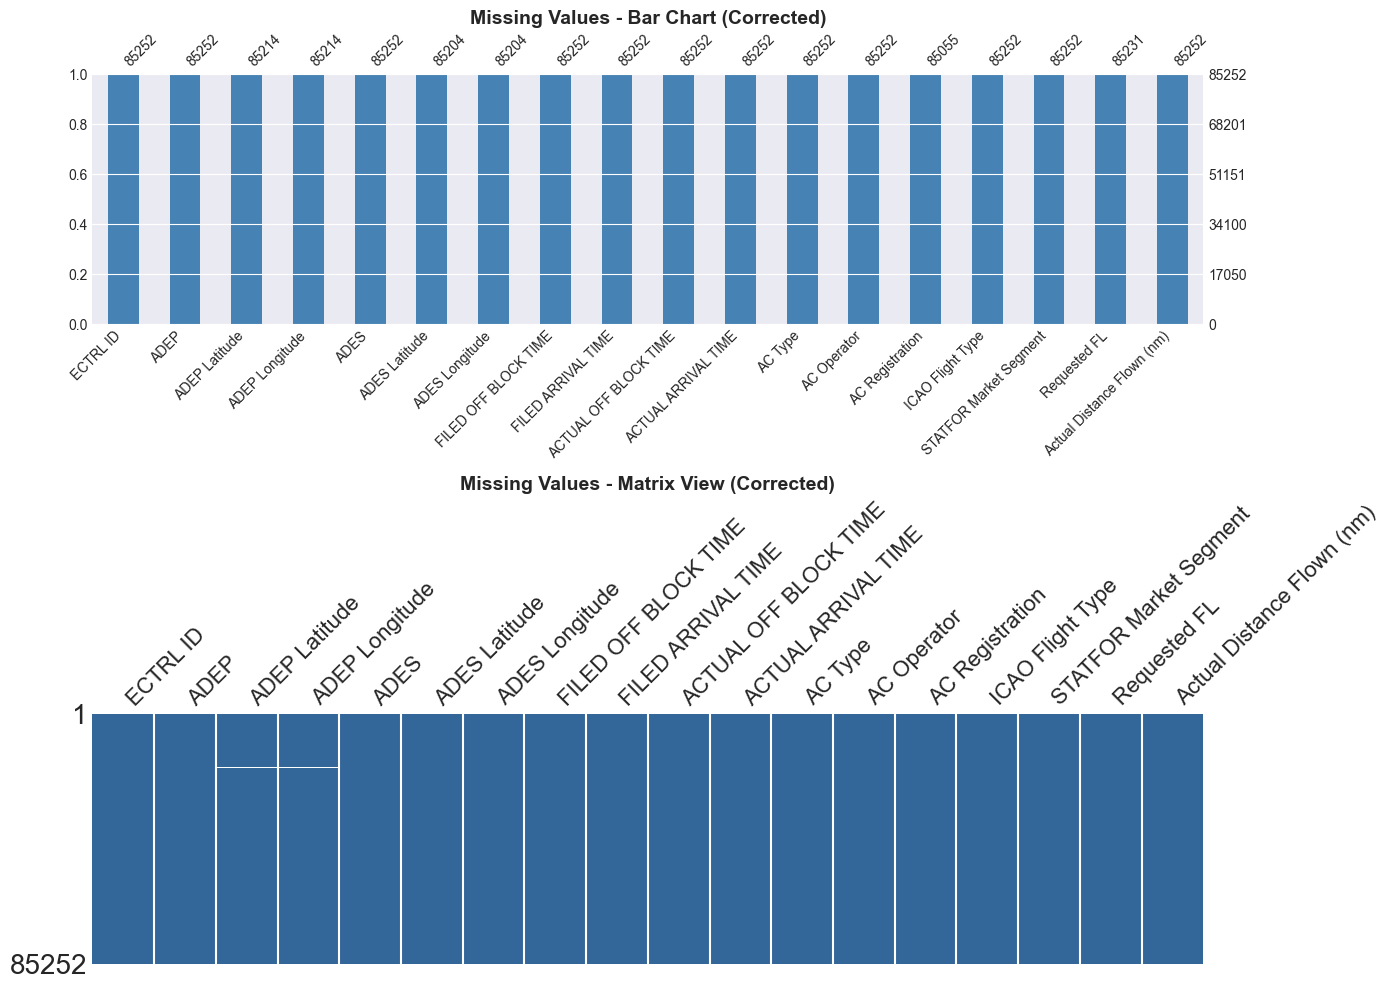

In [ ]:
total_nulls = df.isnull().sum().sum()
print(f" Total NaNs detected before cleaning: {total_nulls}")

hidden_nulls = ['', ' ', '?', 'NA', 'NULL', 'null', 'nan', 'None']

# Replace them in the dataframe
df = df.replace(hidden_nulls, np.nan)

# ---------------------------------------------------------
# NOW run your visualization code
# ---------------------------------------------------------
try:
    import missingno as msno
    
    # Check if we actually created any NaNs
    total_nulls = df.isnull().sum().sum()
    print(f" Total NaNs detected after cleaning: {total_nulls}")

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # Bar plot (Log scale sometimes helps if differences are small, but let's stick to standard)
    msno.bar(df, ax=axes[0], color='steelblue', fontsize=10)
    axes[0].set_title('Missing Values - Bar Chart (Corrected)', fontsize=14, fontweight='bold')
    
    # Null matrix
    msno.matrix(df, ax=axes[1], sparkline=False, color=(0.2, 0.4, 0.6))
    axes[1].set_title('Missing Values - Matrix View (Corrected)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()

except ImportError:
    print("⚠️ Please install missingno: pip install missingno")

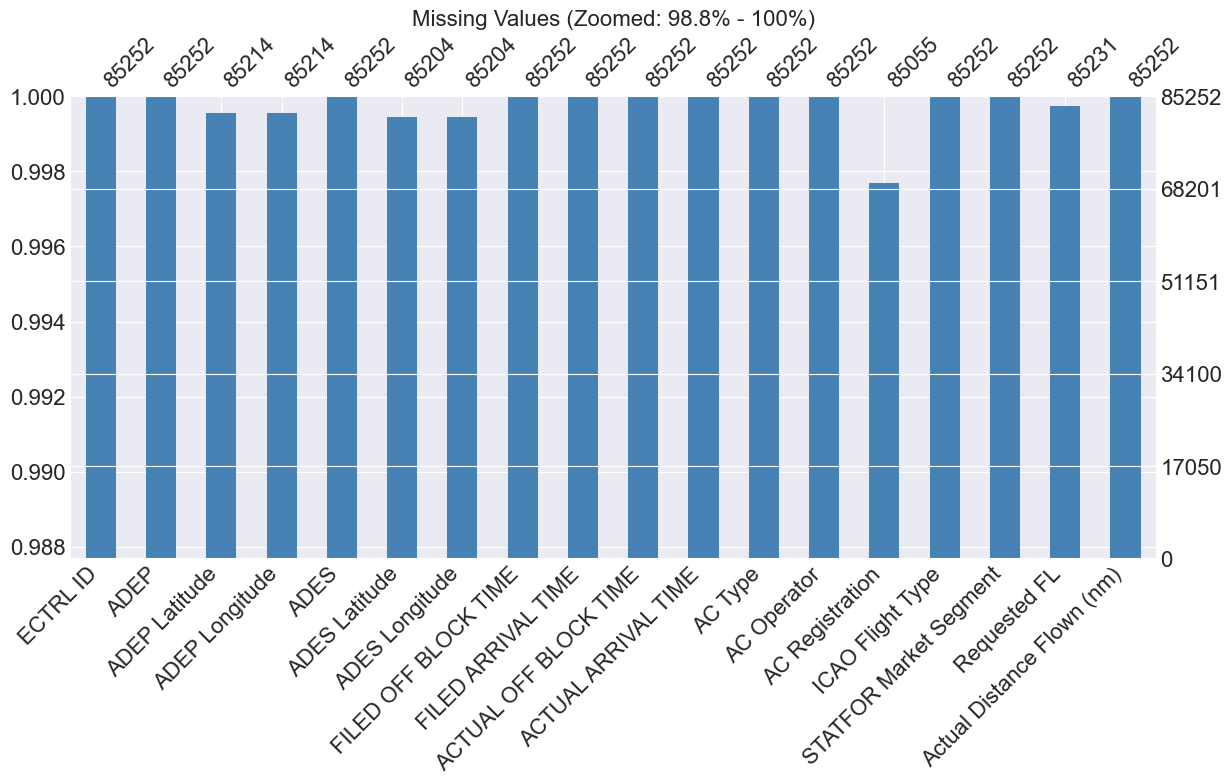

In [ ]:
# The data seems to be almost clean, so the previous representation is not useful.
# Set the scale automatically
min_completion = df.count().min() / len(df)
# Subtract a tiny bit (0.01) to make sure the bar shows
bottom_limit = max(0, min_completion - 0.01) 
fig, ax = plt.subplots(figsize=(14, 6))
# Generate the bar chart
msno.bar(df, ax=ax, color='steelblue')
#Zoom in to the top part 
ax.set_ylim(bottom_limit, 1.0) 

plt.title(f'Missing Values (Zoomed: {bottom_limit*100:.1f}% - 100%)', fontsize=16)
plt.savefig('../reports/02_missing_values.png', dpi=300, bbox_inches='tight')
plt.show()


## Adding delay cols

In [25]:
time_cols = ['FILED ARRIVAL TIME', 'ACTUAL ARRIVAL TIME', 'FILED OFF BLOCK TIME', 'ACTUAL OFF BLOCK TIME']

for col in time_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

# 2. Calculate ARRIVAL DELAY (Target Variable)
# Formula: Actual Arrival - Scheduled (Filed) Arrival
df['Arrival_Delay_Min'] = (df['ACTUAL ARRIVAL TIME'] - df['FILED ARRIVAL TIME']).dt.total_seconds() / 60

# 3. (Optional) Calculate DEPARTURE DELAY 
# This can be a useful feature to predict arrival delay (late leave = late arrival?)
df['Departure_Delay_Min'] = (df['ACTUAL OFF BLOCK TIME'] - df['FILED OFF BLOCK TIME']).dt.total_seconds() / 60

In [30]:
# some statistics of delay
print(df['Arrival_Delay_Min'].describe())

# Check for extreme values
huge_delays = df[df['Arrival_Delay_Min'].abs() > 1200]
print(f"\n Potential date anomalies detected: {len(huge_delays)}")

count    85252.000000
mean         2.316913
std         17.030220
min       -814.383333
25%         -6.933333
50%          0.750000
75%          9.283333
max        946.383333
Name: Arrival_Delay_Min, dtype: float64

 Potential date anomalies detected: 0


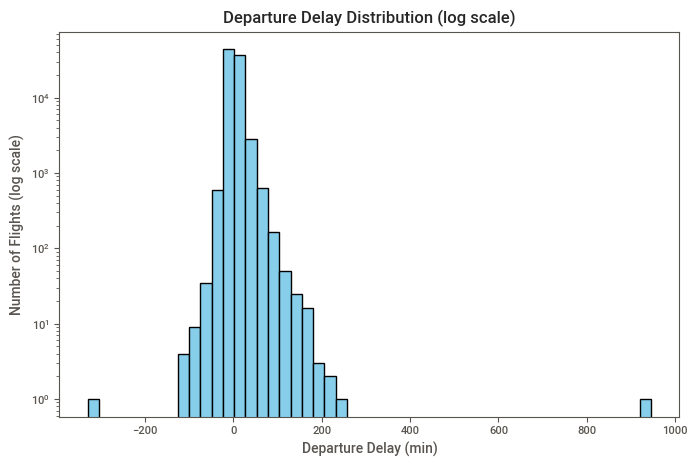

In [34]:
import matplotlib.pyplot as plt

# Use the computed departure delays column
dep_delays = df['Departure_Delay_Min'].dropna()

plt.figure(figsize=(8,5))
plt.hist(dep_delays, bins=50, log=True, color='skyblue', edgecolor='black')
plt.xlabel("Departure Delay (min)")
plt.ylabel("Number of Flights (log scale)")
plt.title("Departure Delay Distribution (log scale)")
plt.savefig('../reports/02_delay_dep_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

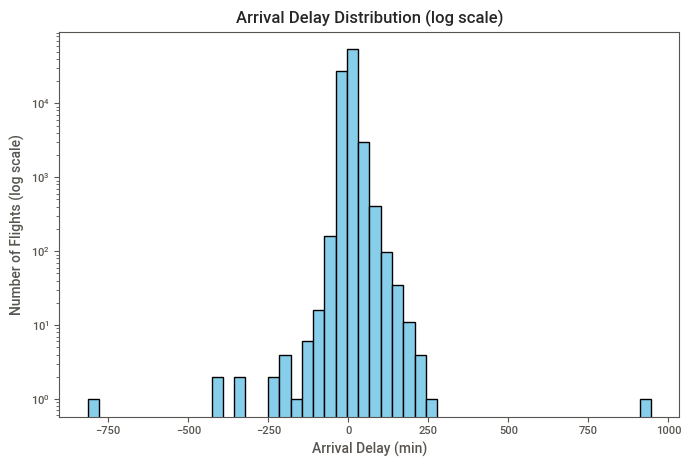

In [35]:
arr_delays = df['Arrival_Delay_Min'].dropna()

plt.figure(figsize=(8,5))
plt.hist(arr_delays, bins=50, log=True, color='skyblue', edgecolor='black')
plt.xlabel("Arrival Delay (min)")
plt.ylabel("Number of Flights (log scale)")
plt.title("Arrival Delay Distribution (log scale)")
plt.savefig('../reports/02_delay_arr_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

## Outliers

In [26]:

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numeric cols: {len(numeric_cols)}")

def detect_outliers_iqr(data, column):
    """outliers using IQR"""
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    
    return {
        'column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower_bound,
        'upper_bound': upper_bound,
        'n_outliers': len(outliers),
        'pct_outliers': (len(outliers) / len(data) * 100)
    }

print("=" * 80)
print("IQR")
print("=" * 80)

outlier_results_iqr = []
for col in numeric_cols:
    if df[col].notna().sum() > 0:  # only if there are non-null values
        result = detect_outliers_iqr(df, col)
        outlier_results_iqr.append(result)

        if result['pct_outliers'] > 1:  # only show if >1% outliers
            print(f"\nCOL {col}:")
            print(f"   IQR: {result['IQR']:.2f}")
            print(f"   Normal range: [{result['lower_bound']:.2f}, {result['upper_bound']:.2f}]")
            print(f"   Outliers: {result['n_outliers']:,} ({result['pct_outliers']:.2f}%)")



Numeric cols: 9
IQR

COL ADEP Latitude:
   IQR: 11.41
   Normal range: [23.35, 69.00]
   Outliers: 2,492 (2.92%)

COL ADEP Longitude:
   IQR: 19.96
   Normal range: [-30.13, 49.71]
   Outliers: 6,006 (7.04%)

COL ADES Latitude:
   IQR: 11.41
   Normal range: [23.35, 69.00]
   Outliers: 2,485 (2.91%)

COL ADES Longitude:
   IQR: 20.45
   Normal range: [-30.84, 50.95]
   Outliers: 5,663 (6.64%)

COL Requested FL:
   IQR: 90.00
   Normal range: [145.00, 505.00]
   Outliers: 4,405 (5.17%)

COL Actual Distance Flown (nm):
   IQR: 841.00
   Normal range: [-952.50, 2411.50]
   Outliers: 10,165 (11.92%)

COL Arrival_Delay_Min:
   IQR: 16.22
   Normal range: [-31.26, 33.61]
   Outliers: 3,544 (4.16%)

COL Departure_Delay_Min:
   IQR: 13.00
   Normal range: [-24.50, 27.50]
   Outliers: 4,289 (5.03%)


In [27]:


def detect_outliers_zscore(data, column, threshold=3):
    """outliers using Z-score"""
    mean = data[column].mean()
    std = data[column].std()
    
    z_scores = np.abs((data[column] - mean) / std)
    outliers = data[z_scores > threshold]
    
    return {
        'column': column,
        'mean': mean,
        'std': std,
        'threshold': threshold,
        'n_outliers': len(outliers),
        'pct_outliers': (len(outliers) / len(data) * 100)
    }

print("\n" + "=" * 80)
print("Z-SCORE (threshold=3)")
print("=" * 80)

outlier_results_zscore = []
for col in numeric_cols:
    if df[col].notna().sum() > 0:
        result = detect_outliers_zscore(df, col)
        outlier_results_zscore.append(result)
        
        if result['pct_outliers'] > 1:
            print(f"\nCOL {col}:")
            print(f"   Mean : {result['mean']:.2f}")
            print(f"   Std: {result['std']:.2f}")
            print(f"   Outliers: {result['n_outliers']:,} ({result['pct_outliers']:.2f}%)")



Z-SCORE (threshold=3)

COL ADEP Latitude:
   Mean : 45.51
   Std: 10.79
   Outliers: 1,202 (1.41%)

COL ADEP Longitude:
   Mean : 9.42
   Std: 24.94
   Outliers: 3,291 (3.86%)

COL ADES Latitude:
   Mean : 45.47
   Std: 10.85
   Outliers: 1,168 (1.37%)

COL ADES Longitude:
   Mean : 9.81
   Std: 24.67
   Outliers: 3,187 (3.74%)

COL Requested FL:
   Mean : 314.78
   Std: 80.24
   Outliers: 1,154 (1.35%)

COL Actual Distance Flown (nm):
   Mean : 1061.08
   Std: 1273.28
   Outliers: 2,750 (3.23%)

COL Arrival_Delay_Min:
   Mean : 2.32
   Std: 17.03
   Outliers: 1,119 (1.31%)

COL Departure_Delay_Min:
   Mean : 2.83
   Std: 14.49
   Outliers: 1,317 (1.54%)


File saved : reports/02_outliers_boxplots.png


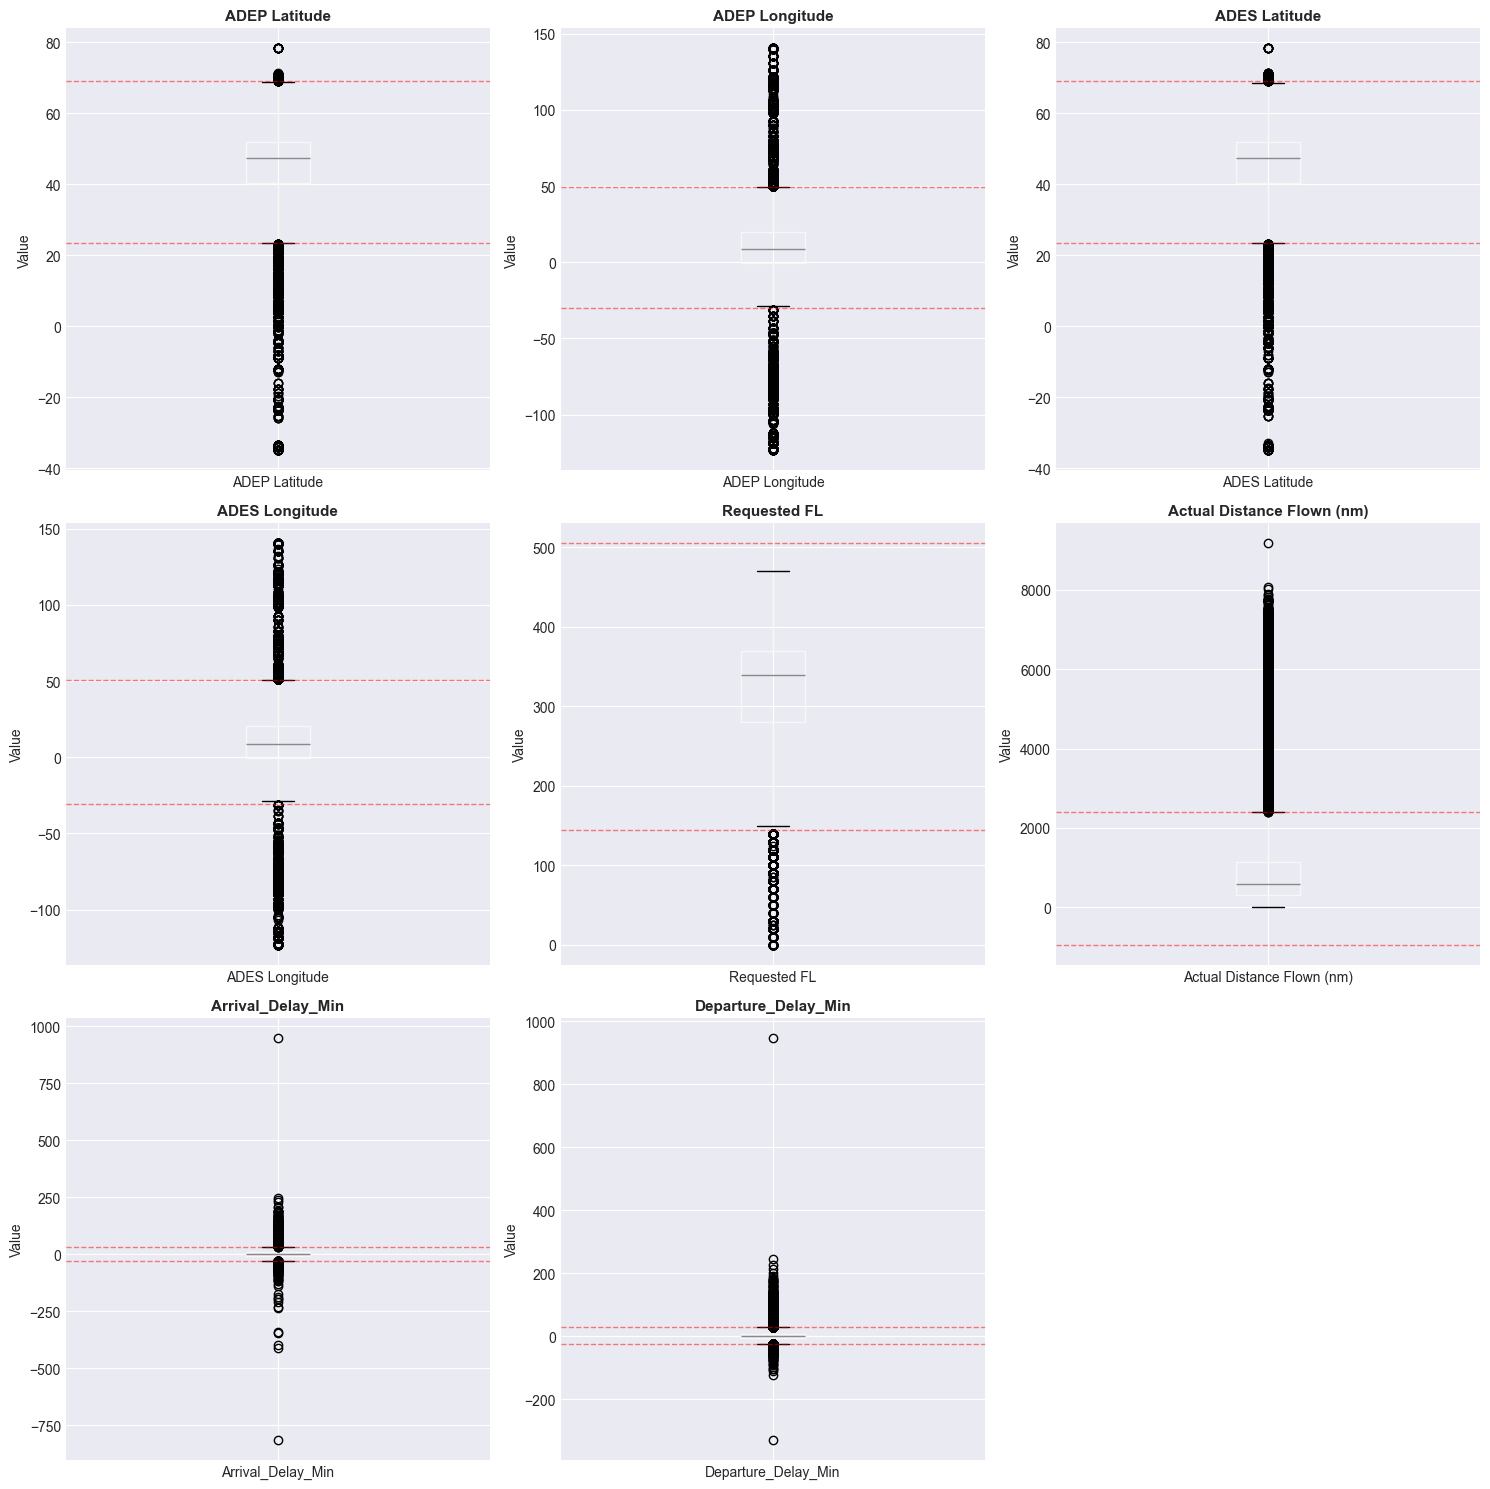

In [28]:
#Visualization of Outliers using Boxplots
import math
import matplotlib.pyplot as plt

# 1. Select columns (All numeric columns except 'ECTRL ID')
cols_to_plot = [col for col in numeric_cols if col != 'ECTRL ID']
n_plots = len(cols_to_plot)

if n_plots > 0:
    # 2. Configure Dynamic Grid
    n_cols = 3  
    n_rows = math.ceil(n_plots / n_cols)  #  necessary rows
    
    # Adjust figure height based on number of rows 
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    
    axes = axes.flatten()

    for idx, col in enumerate(cols_to_plot):
        ax = axes[idx]
        
        # Generate Boxplot
        df.boxplot(column=col, ax=ax)
        ax.set_title(f'{col}', fontsize=11, fontweight='bold')
        ax.set_ylabel('Value')
        
        # IQR Reference Lines
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        
        # Draw theoretical outlier limits (1.5 * IQR) - red lines
        ax.axhline(Q1 - 1.5*IQR, color='red', linestyle='--', alpha=0.5, linewidth=1)
        ax.axhline(Q3 + 1.5*IQR, color='red', linestyle='--', alpha=0.5, linewidth=1)

    # 3. Remove empty subplots 
    for i in range(n_plots, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.savefig('../reports/02_outliers_boxplots.png', dpi=300, bbox_inches='tight')
    print(f"File saved : reports/02_outliers_boxplots.png")
    plt.show()

else:
    print("No numeric columns found to plot.")

## Sweetviz report

In [ ]:
import sweetviz as sv

if not hasattr(np, "VisibleDeprecationWarning"):
    np.VisibleDeprecationWarning = UserWarning #solution to an error

print("Generating Sweetviz report...")

# 1. Analyze the dataframe
analysis = sv.analyze(df)

# 2. Save the report
analysis.show_html('../reports/02_aviation_sweetviz_report.html')

print("Report saved: reports/02_aviation_sweetviz_report.html")

Generating Sweetviz report...


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report ../reports/aviation_sweetviz_report.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.
Report saved: reports/aviation_sweetviz_report.html


## Skew

 SKEWNESS REPORT (Threshold > 1.0 is highly skewed)
--------------------------------------------------
Departure_Delay_Min           5.306042
Actual Distance Flown (nm)    2.293861
Arrival_Delay_Min             1.637584
ECTRL ID                     -0.014142
ADES Longitude               -0.552936
ADEP Longitude               -0.659570
Requested FL                 -1.397773
ADEP Latitude                -1.591576
ADES Latitude                -1.623402
dtype: float64
--------------------------------------------------

Candidates for Log Transformation: ['Departure_Delay_Min', 'Actual Distance Flown (nm)', 'Arrival_Delay_Min', 'Requested FL', 'ADEP Latitude', 'ADES Latitude']

 SKIPPING Departure_Delay_Min: Contains negative values (cannot apply simple log).


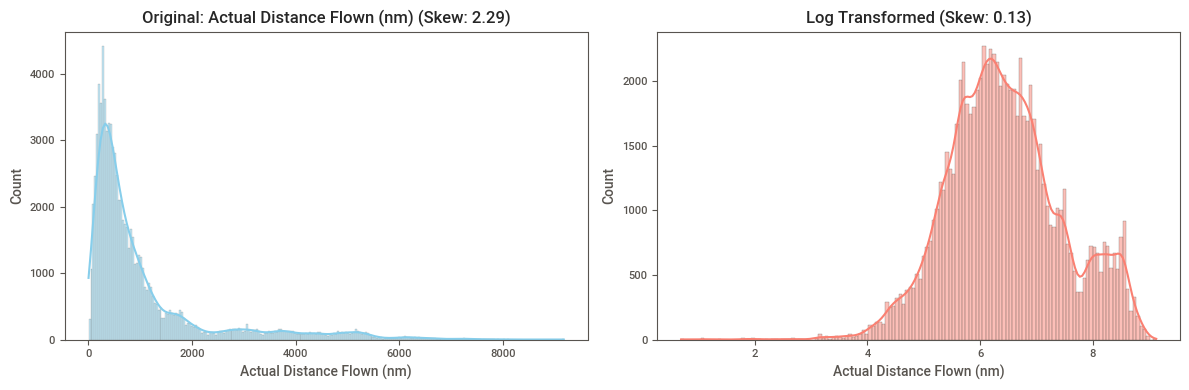


 SKIPPING Arrival_Delay_Min: Contains negative values (cannot apply simple log).


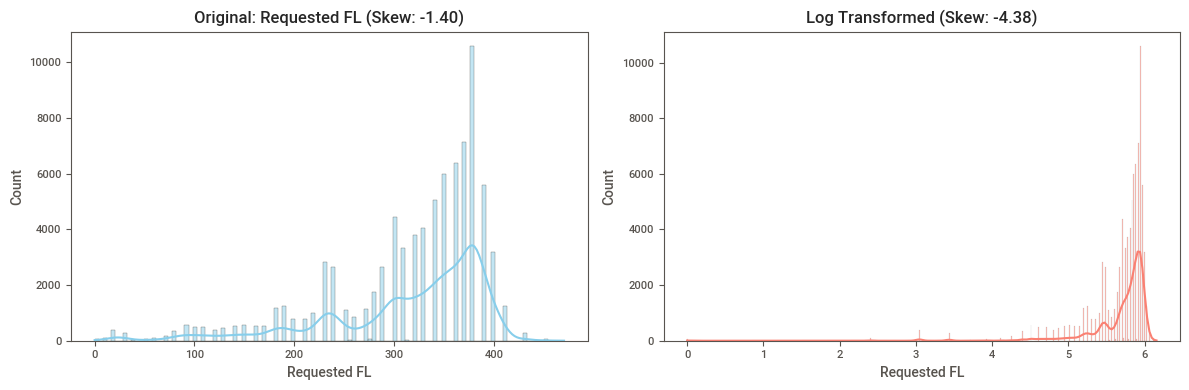


 SKIPPING ADEP Latitude: Contains negative values (cannot apply simple log).

 SKIPPING ADES Latitude: Contains negative values (cannot apply simple log).


In [36]:
import numpy as np

# 1. Calculate Skewness for all numeric columns
# Drop NaNs to calculate correctly
numeric_df = df.select_dtypes(include=['float64', 'int64'])
skewness = numeric_df.skew().sort_values(ascending=False)

print(" SKEWNESS REPORT (Threshold > 1.0 is highly skewed)")
print("-" * 50)
print(skewness)
print("-" * 50)

# 2. Filter highly skewed columns (absolute value > 1)
#  exclude 'ECTRL ID'
high_skew_cols = skewness[abs(skewness) > 1].index.tolist()
high_skew_cols = [c for c in high_skew_cols if 'ID' not in c]

print(f"\nCandidates for Log Transformation: {high_skew_cols}")

# 3. Visualization: Before vs After Log Transform
if high_skew_cols:
    for col in high_skew_cols:
        # Check if column has negative values (Log doesn't work on negatives)
        if df[col].min() < 0:
            print(f"\n SKIPPING {col}: Contains negative values (cannot apply simple log).")
            continue

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        
        # Original Distribution
        sns.histplot(df[col], kde=True, ax=axes[0], color='skyblue')
        axes[0].set_title(f'Original: {col} (Skew: {skewness[col]:.2f})')
        
        # Log Transformed Distribution (np.log1p handles zeros)
        # log1p calculates log(1 + x)
        log_data = np.log1p(df[col])
        new_skew = log_data.skew()
        
        sns.histplot(log_data, kde=True, ax=axes[1], color='salmon')
        axes[1].set_title(f'Log Transformed (Skew: {new_skew:.2f})')
        
        plt.tight_layout()
        plt.show()
else:
    print(" No highly skewed columns found.")

Since delay columns have negative values, Im going to try to use Yeo transform, so I can lower the skew.

✅ Applying Log transform to Distance...
✅ Applying Yeo-Johnson transform to: ['Departure_Delay_Min', 'Arrival_Delay_Min']


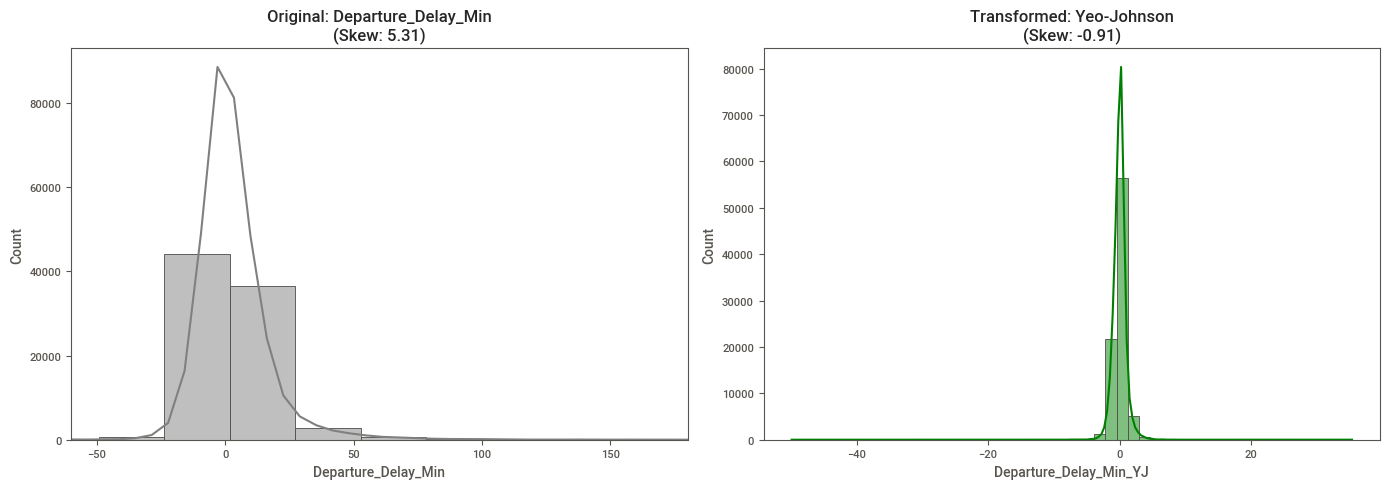

In [38]:
from sklearn.preprocessing import PowerTransformer

# 1. Apply Log to Distance (Safe for positive values)
# We create a new column so we don't lose the original
print("✅ Applying Log transform to Distance...")
df['Log_Actual_Distance'] = np.log1p(df['Actual Distance Flown (nm)'])

# 2. Apply Yeo-Johnson to Delays (Handles negative values)
# We use sklearn's PowerTransformer
pt = PowerTransformer(method='yeo-johnson')

cols_to_fix = ['Departure_Delay_Min', 'Arrival_Delay_Min']
print(f"✅ Applying Yeo-Johnson transform to: {cols_to_fix}")

# Create new columns with suffix '_YJ'
for col in cols_to_fix:
    # Reshape is needed because fit_transform expects 2D array
    data_reshaped = df[[col]].values
    df[f'{col}_YJ'] = pt.fit_transform(data_reshaped)

# -------------------------------------------------------
# 3. VISUAL CHECK: Did it work?
# -------------------------------------------------------
check_cols = ['Departure_Delay_Min', 'Departure_Delay_Min_YJ']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original
sns.histplot(df[check_cols[0]], bins=50, kde=True, ax=axes[0], color='gray')
axes[0].set_title(f'Original: {check_cols[0]}\n(Skew: {df[check_cols[0]].skew():.2f})')
axes[0].set_xlim(-60, 180) # Zoom in to see the main distribution

# Transformed
sns.histplot(df[check_cols[1]], bins=50, kde=True, ax=axes[1], color='green')
axes[1].set_title(f'Transformed: Yeo-Johnson\n(Skew: {df[check_cols[1]].skew():.2f})')

plt.tight_layout()
plt.savefig('../reports/02_skew_yeo_transform.png', dpi=300, bbox_inches='tight')
plt.show()

## Correlations

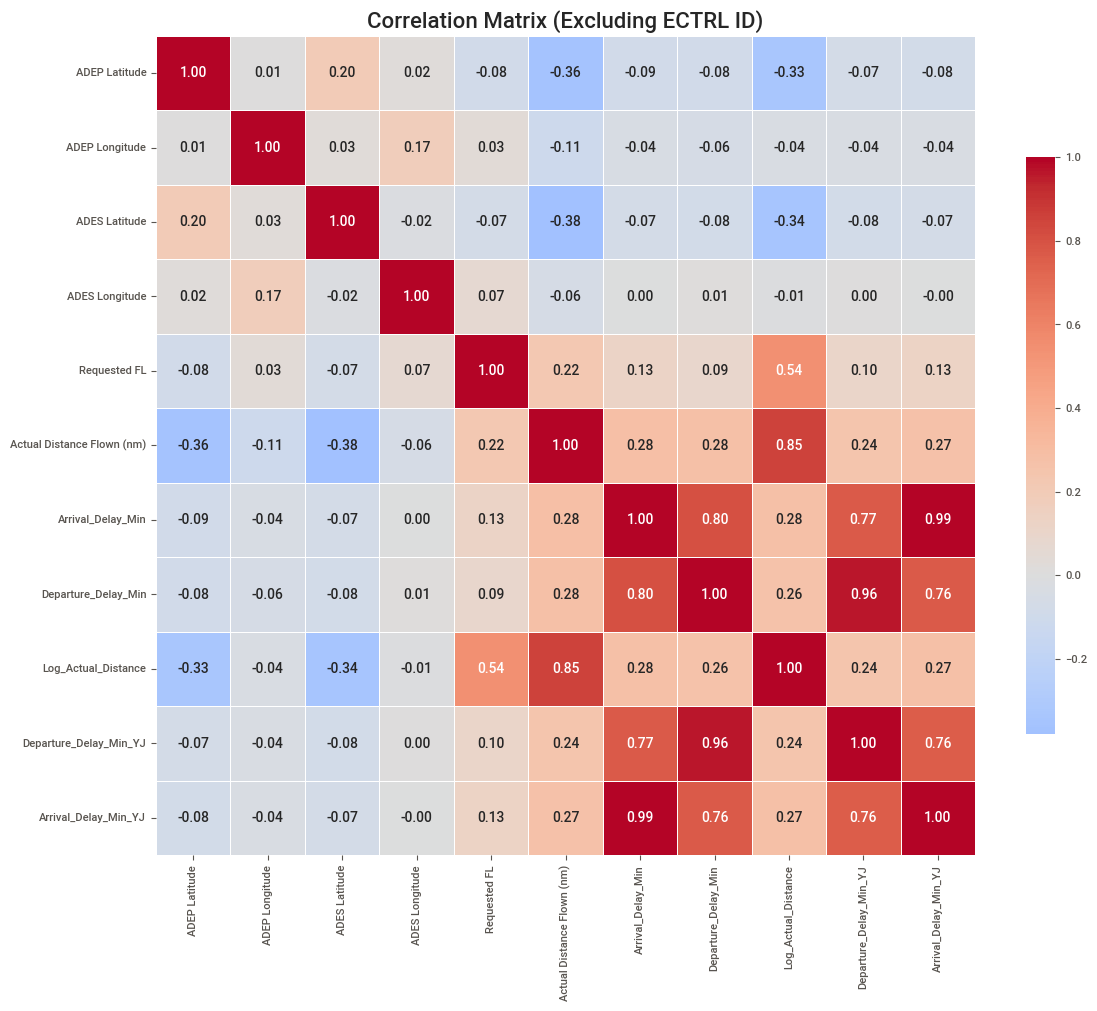


 Top correlations with 'Arrival_Delay_Min':
--------------------------------------------------
Arrival_Delay_Min             1.000000
Arrival_Delay_Min_YJ          0.989325
Departure_Delay_Min           0.801256
Departure_Delay_Min_YJ        0.770455
Actual Distance Flown (nm)    0.284314
Log_Actual_Distance           0.282234
Requested FL                  0.125795
ADES Longitude                0.003155
ADEP Longitude               -0.044000
ADES Latitude                -0.070898
ADEP Latitude                -0.089485
dtype: float64

 Top correlations with 'Departure_Delay_Min':
--------------------------------------------------
Departure_Delay_Min           1.000000
Departure_Delay_Min_YJ        0.957887
Arrival_Delay_Min             0.801256
Arrival_Delay_Min_YJ          0.764852
Actual Distance Flown (nm)    0.275404
Log_Actual_Distance           0.262268
Requested FL                  0.093621
ADES Longitude                0.014627
ADEP Longitude               -0.056374
ADES Latitu

In [43]:
# 1. Select numeric columns
numeric_df = df.select_dtypes(include=[np.number])

# 2. Drop the specific ID column (using 'errors=ignore' in case it's already gone)
# Make sure the name matches exactly what is in your df.columns (ECTRL ID or ECTR_ID)
cols_to_drop = ['ECTRL ID'] 
numeric_df = numeric_df.drop(columns=cols_to_drop, errors='ignore')

# 3. Calculate Pearson Correlation
corr_matrix = numeric_df.corr(method='pearson')

# 4. Plot Heatmap
plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap='coolwarm', 
    center=0, 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .7}
)

plt.title('Correlation Matrix (Excluding ECTRL ID)', fontsize=16)
plt.tight_layout()
plt.savefig('../reports/02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()


print(f"\n Top correlations with 'Arrival_Delay_Min':")
print("-" * 50)
print(numeric_df.corrwith(numeric_df['Arrival_Delay_Min']).sort_values(ascending=False))
print(f"\n Top correlations with 'Departure_Delay_Min':")
print("-" * 50)
print(numeric_df.corrwith(numeric_df['Departure_Delay_Min']).sort_values(ascending=False))


# Insights for numerical columns

## 1. Data quality
All the columns have less than 5% of null values. I can delete the ones that doesn't have arrival or departure date, or not airport info.
All the null values seem to be NaN, but later I can make more comparisons when a I compare the ICAO codes of the fact table to the dim ones.
AC Registration is the column with more nulls, not a key column for statistics. I can keep those rows.


## 2. Outliers 
1. ADEP Latitude (2.92% outliers)

Decision: KEEP if coordinates <90
Reasoning: The range [23.35, 69.00] covers Europe/North Africa comfortably. Outliers likely represent legitimate flights to further destinations. Unless coordinates are impossible (>90), these are real airports.

2. ADEP Longitude (7.04% outliers)

Decision: KEEP if coordinates<180

Reasoning: Similar to latitude, the "normal range" [-30, 49] is roughly the European bounding box. Outliers are just long-haul flights or destinations outside the core EUROCONTROL area. 

3. ADES Latitude (2.91% outliers)
Decision: KEEP if coordinates<90

4. ADES Longitude (6.64% outliers)

Decision: KEEP if coordinates<180

Reasoning: Same logic as ADEP. Do not remove unless values are geographically impossible (e.g., >180).

5. Requested FL (Flight Level) (5.17% outliers) 

Decision: FILTER (Remove impossible low values: keep > FL100 and <600) 

Reasoning: The range [145, 505] suggests most flights are cruising high. Outliers below 145 (FL145) might be VFR flights, short hops, or data errors (e.g., FL0). 

I want to model only commercial jets (keep > FL100) .


6. Actual Distance Flown (nm) (11.92% outliers)

Decision: KEEP (Log-transform later)

Reasoning: 11.9% is a huge chunk of data. The "normal range" upper limit is ~2,400 nm. Long-haul flights naturally exceed this. They are not errors; they are just long flights.

Action: Do not remove. Use a Log transformation during feature engineering to handle the skew.

7. Arrival_Delay_Min (4.16% outliers)

Decision: KEEP, check only for >2 days

Reasoning:  The "outliers" are exactly the critical cases for my model to learn. 


8. Departure_Delay_Min (5.03% outliers)

Decision: KEEP, check only for >2 days

Reasoning: Same as Arrival Delay. 

## 3. Data Types
- FILED OFF BLOCK TIME, FILED ARRIVAL TIME, ACTUAL OFF BLOCK TIME, and ACTUAL ARRIVAL TIME are currently type object (strings). Need conversion to datetime.
- STATFOR Market Segment, ICAO Flight Type, or AC Type likely have a limited number of unique values repeated many times.
Current state: object (High memory usage). Ill try  to convert them to category.

## 4. Distributions
High Positive Skew (Right-tailed):
- Departure_Delay_Min (Skew: 5.31)
- Actual Distance Flown (nm) (Skew: 2.29)
- Arrival_Delay_Min (Skew: 1.64)

Negative Skew (Left-tailed):
- Requested FL (Skew: -1.40)
- ADEP/ADES Latitude (Skew: ~ -1.6)

Latitudes Im not going to transform it since it represent geogrpahical info.
Delays i'm using Yeo-Johnson transformation.
Distance and fl: log transform

## 5. Correlations
As expected, Departure Delay is the dominant driver of Arrival Delay . This strong positive linear relationship confirms that delays generated on the ground propagate directly to the arrival phase.
There is a moderate positive correlation ($r \approx 0.28$) between Actual Distance Flown and delays. This suggests that longer flights have a slightly higher tendency to accumulate delays.
Geographical coordinates (Latitude/Longitude) show negligible correlation with delay. Specific airport congestion or route characteristics are likely more relevant than raw coordinates.


## 7. Next Steps 
Analyze non numerical data.
Try to use the complete dataset with PySpark



